# PAP_NER + multi-backbone classification head (softmax)

Notebook dùng chung một pipeline PAP_NER để so sánh 4 backbone: **BamiBERT, ELECTRA (vELECTRA), XLM-R và PhoBERT v2**. Chọn backbone tại biến `MODEL_CHOICE` trong cell cấu hình; dữ liệu, cách đọc CoNLL, tiền xử lý/căn nhãn subword, lịch huấn luyện và metric được giữ như baseline trước.

Thay đổi kiến trúc duy nhất so với các baseline CRF là bỏ CRF: encoder được nối với cùng một linear classification head, học bằng cross-entropy trên vị trí từ hợp lệ và dự đoán bằng argmax độc lập theo từ. Không có ràng buộc chuyển tiếp BIO.

- Mặc định chọn `phobert_v2`; checkpoint: `vinai/phobert-base-v2`.
- Các lựa chọn khác có checkpoint Hugging Face trong `MODEL_REGISTRY`.
- Chỉ chạy trên RTX 3090 24 GB: physical batch `32`, gradient accumulation `1`, effective batch `32`.
- Mặc định huấn luyện 20 epochs. Giữ cùng seed, số epochs và thiết lập để so sánh công bằng.

Mỗi model có run directory riêng. Khi đổi model, chạy từ cell cấu hình trở xuống để notebook nạp đúng tokenizer/model và tạo lại config. Kiểm tra checkpoint trong registry trước khi bắt đầu; có thể thay ID bằng đường dẫn checkpoint local nếu cần.


## 1. GPU và cấu hình thí nghiệm


In [1]:
from pathlib import Path
import json, os, shutil, subprocess, sys, time

# =========================
# BACKBONE SELECTION
# =========================
MODEL_REGISTRY = {
    "bamibert": {
        "model_name_or_path": "Qualcomm-AI-Research/BamiBERT",
        "use_fast_tokenizer": True,
    },
    "electra": {
        "model_name_or_path": "FPTAI/velectra-base-discriminator-cased",
        "use_fast_tokenizer": False,
    },
    "xlm_r": {
        "model_name_or_path": "FacebookAI/xlm-roberta-base",
        "use_fast_tokenizer": False,
    },
    "phobert_v2": {
        "model_name_or_path": "vinai/phobert-base-v2",
        "use_fast_tokenizer": False,
    },
}
MODEL_CHOICE = "electra"  # bamibert | electra | xlm_r | phobert_v2
if MODEL_CHOICE not in MODEL_REGISTRY:
    raise ValueError(f"MODEL_CHOICE không hợp lệ: {MODEL_CHOICE}; chọn một trong {list(MODEL_REGISTRY)}")
SELECTED_MODEL = MODEL_REGISTRY[MODEL_CHOICE]

# =========================
# USER CONFIG
# =========================
GPU_PROFILE = "rtx3090_24gb"
TRIAL_EPOCHS = 20
RESUME = False

HF_DATASET_REPO = "Leekien0108/PAP_NER"
HF_DATASET_REVISION = "7a0f6b1233667702925baa69c07c55d5d26eb6cd"
CUSTOM_DATA_DIR = None     # optional: folder containing train_data.txt/dev_data.txt/test_data.txt

# =========================
# Linux / GPU detection
# =========================
if sys.platform != "linux":
    raise RuntimeError("Notebook này được cấu hình cho Linux.")

try:
    gpu_rows = subprocess.check_output(
        ["nvidia-smi", "--query-gpu=name,memory.total", "--format=csv,noheader,nounits"],
        text=True,
    ).strip().splitlines()
except Exception as exc:
    raise RuntimeError("Không gọi được nvidia-smi. Hãy kiểm tra NVIDIA driver / GPU runtime.") from exc

if not gpu_rows:
    raise RuntimeError("Không phát hiện GPU NVIDIA.")

gpu_name_raw, gpu_mem_mib_raw = [x.strip() for x in gpu_rows[0].split(",", 1)]
GPU_NAME = gpu_name_raw
GPU_VRAM_GIB = float(gpu_mem_mib_raw) / 1024.0

if "RTX 3090" not in GPU_NAME.upper():
    raise RuntimeError(f"Notebook này chỉ hỗ trợ RTX 3090; GPU phát hiện: {GPU_NAME}.")

TRAIN_BATCH_SIZE = 32
EVAL_BATCH_SIZE = 32
GRAD_ACCUM_STEPS = 1
GRADIENT_CHECKPOINTING = False
TORCH_VERSION = "2.5.1"
TORCH_INDEX = "cu121"
MIN_EXPECTED_VRAM_GIB = 22.0

if GPU_VRAM_GIB < MIN_EXPECTED_VRAM_GIB:
    raise RuntimeError(
        f"VRAM phát hiện {GPU_VRAM_GIB:.1f} GiB, thấp hơn mức mong đợi cho {GPU_PROFILE}."
    )

# =========================
# Paths
# =========================
NOTEBOOK_DIR = Path.cwd()
default_root = Path("/workspace/ner-pap") if Path("/workspace").exists() else NOTEBOOK_DIR / "ner-pap"
WORK_ROOT = Path(os.environ.get("NER_WORK_ROOT", str(default_root))).resolve()
WORK_ROOT.mkdir(parents=True, exist_ok=True)

RUN_NAME = f"papner_{MODEL_CHOICE}_softmax_{TRIAL_EPOCHS}ep_{GPU_PROFILE}"
RUN_DIR = WORK_ROOT / "runs" / RUN_NAME
RUN_DIR.mkdir(parents=True, exist_ok=True)

# =========================
# Reproduction config
# =========================
CFG = {
    "model_name_or_path": SELECTED_MODEL["model_name_or_path"],
    "model_choice": MODEL_CHOICE,
    "use_fast_tokenizer": SELECTED_MODEL["use_fast_tokenizer"],
    "max_seq_length": 256,
    "train_batch_size": TRAIN_BATCH_SIZE,
    "eval_batch_size": EVAL_BATCH_SIZE,
    "gradient_accumulation_steps": GRAD_ACCUM_STEPS,
    "gradient_checkpointing": GRADIENT_CHECKPOINTING,
    "precision": "fp16",
    "learning_rate": 2e-5,
    "classifier_learning_rate": 1e-3,
    "epochs": TRIAL_EPOCHS,
    "early_stop": 5,
    "warmup_proportion": 0.1,
    "weight_decay": 0.01,
    "adam_epsilon": 1e-6,
    "max_grad_norm": 1.0,
    "dropout": 0.1,
    "seed": 42,
    "num_workers": 2,
    "device": "cuda",
    "smoke_batches": 2,
    "train_limit": None,
    "dev_limit": None,
    "cpu_threads": 4,
    # The setup file states Strict Micro F1 is the main metric.
    # It does not explicitly state checkpoint-selection criterion,
    # so this notebook uses dev Strict Micro F1 for best-checkpoint selection.
    "selection_metric": "entity_strict_micro_f1",
    "resume": RESUME,
}

assert CFG["train_batch_size"] * CFG["gradient_accumulation_steps"] == 32
assert CFG["precision"] == "fp16"
assert CFG["epochs"] == TRIAL_EPOCHS
assert CFG["max_seq_length"] == 256

CFG.update(
    dataset_repo=HF_DATASET_REPO,
    dataset_requested_revision=HF_DATASET_REVISION,
    dataset_revision=None,
    data_files={},
    output_dir=str(RUN_DIR),
    cache_dir=str(WORK_ROOT / "feature-cache"),
)

CONFIG_PATH = RUN_DIR / "launch_config.json"
CONFIG_PATH.write_text(json.dumps(CFG, ensure_ascii=False, indent=2), encoding="utf-8")

ENV_DIR = WORK_ROOT / f"venv-papner-torch{TORCH_VERSION}-{TORCH_INDEX}"
ENV_PYTHON = ENV_DIR / "bin" / "python"
RUNNER = WORK_ROOT / "papner_multimodel_classifier_runner.py"

ENV = dict(
    os.environ,
    HF_HOME=str(WORK_ROOT / "hf-cache"),
    TOKENIZERS_PARALLELISM="false",
    PYTHONUNBUFFERED="1",
    PYTHONIOENCODING="utf-8",
    CUDA_VISIBLE_DEVICES=os.environ.get("CUDA_VISIBLE_DEVICES", "0"),
    MPLBACKEND="Agg",
    PYTORCH_CUDA_ALLOC_CONF="expandable_segments:True",
)

print(f"Model choice: {MODEL_CHOICE} ({CFG['model_name_or_path']})")
print(f"GPU: {GPU_NAME}")
print(f"VRAM: {GPU_VRAM_GIB:.1f} GiB")
print(f"Profile: {GPU_PROFILE}")
print(f"PyTorch target: {TORCH_VERSION} + {TORCH_INDEX}")
print(f"Train batch: {TRAIN_BATCH_SIZE}")
print(f"Gradient accumulation: {GRAD_ACCUM_STEPS}")
print(f"Effective batch: {TRAIN_BATCH_SIZE * GRAD_ACCUM_STEPS}")
print(f"Epochs: {TRIAL_EPOCHS}")
print(f"Run dir: {RUN_DIR}")

Model choice: electra (FPTAI/velectra-base-discriminator-cased)
GPU: NVIDIA GeForce RTX 3090
VRAM: 24.0 GiB
Profile: rtx3090_24gb
PyTorch target: 2.5.1 + cu121
Train batch: 32
Gradient accumulation: 1
Effective batch: 32
Epochs: 20
Run dir: /workspace/ner-pap/runs/papner_electra_softmax_20ep_rtx3090_24gb


## 2. Tạo môi trường Python

Notebook tạo một `venv` riêng để tránh xung đột package của image Linux hiện tại.

- RTX 3090: dùng PyTorch `2.5.1` + CUDA `12.1`.
- Transformers: `4.44.2`.
- Precision training là **FP16** trên RTX 3090.

Cell này cũng chạy một phép nhân ma trận FP16 trên GPU để xác nhận wheel PyTorch thật sự tương thích với GPU hiện tại.


In [2]:
import platform

def suitable_python(candidate):
    if not candidate or not Path(candidate).is_file():
        return False
    probe = subprocess.run(
        [str(candidate), "-c", "import sys,ensurepip; assert (3,10) <= sys.version_info[:2] <= (3,12)"],
        stdout=subprocess.DEVNULL,
        stderr=subprocess.DEVNULL,
    )
    return probe.returncode == 0

python_candidates = [os.environ.get("NER_PYTHON_BIN"), sys.executable]
python_candidates += [shutil.which(name) for name in ("python3.12", "python3.11", "python3.10")]
python_candidates += [
    str(Path(os.environ.get("CONDA_PREFIX", "/nonexistent")) / "bin" / "python"),
    str(NOTEBOOK_DIR.parent / ".conda" / "bin" / "python"),
]
PYTHON_BIN = next((str(x) for x in python_candidates if suitable_python(x)), None)
if PYTHON_BIN is None:
    raise RuntimeError(
        "Cần Python 3.10–3.12 có venv/ensurepip. "
        "Hãy cài python3-venv hoặc đặt biến NER_PYTHON_BIN."
    )

free_gib = shutil.disk_usage(WORK_ROOT).free / 2**30
if free_gib < 12:
    raise RuntimeError(f"Chỉ còn {free_gib:.1f} GiB trống. Nên có ít nhất 12 GiB.")

if not ENV_PYTHON.exists():
    subprocess.run([PYTHON_BIN, "-m", "venv", str(ENV_DIR)], check=True)

marker = ENV_DIR / ".papner-multimodel-softmax-v1"
if not marker.exists():
    def pip_install(*packages, extra=()):
        subprocess.run(
            [str(ENV_PYTHON), "-m", "pip", "install", *extra, *packages],
            check=True,
            env=ENV,
        )

    pip_install("pip==24.3.1", "setuptools==75.3.0", "wheel==0.45.1", "numpy==1.26.4")
    torch_index_url = f"https://download.pytorch.org/whl/{TORCH_INDEX}"
    pip_install(f"torch=={TORCH_VERSION}", extra=("--index-url", torch_index_url))
    pip_install(
        "numpy==1.26.4",
        "scipy==1.14.1",
        "contourpy==1.3.0",
        "protobuf==5.28.3",
        "transformers==4.44.2",
        "sentencepiece==0.2.0",
        "huggingface_hub==0.36.2",
        "scikit-learn==1.5.2",
        "seqeval==1.2.2",
        "tqdm==4.66.5",
        "tensorboard==2.18.0",
        "matplotlib==3.9.2",
        "pandas==2.2.3",
        "nervaluate==0.2.0",
        "tabulate==0.9.0",
        extra=("--no-build-isolation",),
    )
    marker.write_text("ready", encoding="utf-8")

gpu_check = r"""
import torch
print("torch:", torch.__version__)
print("CUDA runtime in wheel:", torch.version.cuda)
assert torch.cuda.is_available(), "CUDA unavailable"
print("GPU:", torch.cuda.get_device_name(0))
print("VRAM GiB:", torch.cuda.get_device_properties(0).total_memory / 2**30)
print("Capability:", torch.cuda.get_device_capability(0))
print("Compiled archs:", torch.cuda.get_arch_list())

x = torch.randn((512, 512), device="cuda", dtype=torch.float16)
y = x @ x
assert torch.isfinite(y).all(), "FP16 CUDA smoke operation failed"
print("FP16 CUDA smoke op: OK")
"""
subprocess.run([str(ENV_PYTHON), "-c", gpu_check], check=True, env=ENV)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 72.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 89.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 105.2 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 25.0.1
    Uninstalling pip-25.0.1:
      Successfully uninstalled pip-25.0.1



[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: /workspace/ner-pap/venv-papner-torch2.5.1-cu121/bin/python -m pip install --upgrade pip


Looking in indexes: https://download.pytorch.org/whl/cu121
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.4/780.4 MB 92.4 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 105.9 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 257.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 124.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 102.8 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 100.9 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 92.4 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 107.3 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 104.4 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.0 MB 112.3 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 M


[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: /workspace/ner-pap/venv-papner-torch2.5.1-cu121/bin/python -m pip install --upgrade pip


  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Using cached packaging-26.3-py3-none-any.whl.metadata (3.5 kB)
  Using cached urllib3-2.8.0-py3-none-any.whl.metadata (7.4 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 MB 106.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 109.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 89.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 59.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 109.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 102.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 91.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 106.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 103.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2


[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: /workspace/ner-pap/venv-papner-torch2.5.1-cu121/bin/python -m pip install --upgrade pip


torch: 2.5.1+cu121
CUDA runtime in wheel: 12.1
GPU: NVIDIA GeForce RTX 3090
VRAM GiB: 23.55877685546875
Capability: (8, 6)
Compiled archs: ['sm_50', 'sm_60', 'sm_70', 'sm_75', 'sm_80', 'sm_86', 'sm_90']
FP16 CUDA smoke op: OK


CompletedProcess(args=['/workspace/ner-pap/venv-papner-torch2.5.1-cu121/bin/python', '-c', '\nimport torch\nprint("torch:", torch.__version__)\nprint("CUDA runtime in wheel:", torch.version.cuda)\nassert torch.cuda.is_available(), "CUDA unavailable"\nprint("GPU:", torch.cuda.get_device_name(0))\nprint("VRAM GiB:", torch.cuda.get_device_properties(0).total_memory / 2**30)\nprint("Capability:", torch.cuda.get_device_capability(0))\nprint("Compiled archs:", torch.cuda.get_arch_list())\n\nx = torch.randn((512, 512), device="cuda", dtype=torch.float16)\ny = x @ x\nassert torch.isfinite(y).all(), "FP16 CUDA smoke operation failed"\nprint("FP16 CUDA smoke op: OK")\n'], returncode=0)

## 3. Tải PAP_NER từ Hugging Face

Notebook dùng đúng ba split `train / dev / test` đã phát hành. Dataset được ghim theo commit SHA để lần chạy có thể tái lập.

Nếu muốn dùng file local, đặt `CUSTOM_DATA_DIR` ở cell cấu hình thành thư mục chứa:

- `train_data.txt`
- `dev_data.txt`
- `test_data.txt`


In [3]:
if CUSTOM_DATA_DIR is None:
    fetch_script = r"""
import json, sys
from pathlib import Path
from huggingface_hub import HfApi, snapshot_download

repo_id, revision, output_root = sys.argv[1:]
info = HfApi().dataset_info(repo_id, revision=revision)
sha = info.sha
if not sha:
    raise RuntimeError('Hugging Face did not return a dataset commit SHA')
files = [item.rfilename for item in info.siblings]
choices = {
    'train': {'train_data.txt', 'train.txt'},
    'dev': {'dev_data.txt', 'dev.txt', 'validation_data.txt', 'validation.txt'},
    'test': {'test_data.txt', 'test.txt'},
}
selected = {}
for split, names in choices.items():
    matches = [name for name in files if Path(name).name in names]
    if len(matches) != 1:
        raise RuntimeError(f'Expected exactly one CoNLL file for {split}; found {matches}. '
                           f'Dataset files: {files}')
    selected[split] = matches[0]
root = Path(snapshot_download(repo_id=repo_id, repo_type='dataset', revision=sha,
                              local_dir=str(Path(output_root) / sha),
                              allow_patterns=list(selected.values())))
paths = {split: str((root / name).resolve()) for split, name in selected.items()}
for split, path in paths.items():
    if not Path(path).is_file() or Path(path).stat().st_size == 0:
        raise RuntimeError(f'Missing or empty {split} file: {path}')
print(json.dumps({'sha': sha, 'files': paths}, ensure_ascii=False))
"""
    try:
        fetched = subprocess.check_output(
            [str(ENV_PYTHON), '-c', fetch_script, HF_DATASET_REPO, HF_DATASET_REVISION,
             str(WORK_ROOT / 'hf-datasets')], text=True, env=ENV)
    except subprocess.CalledProcessError as exc:
        raise RuntimeError('Không tải được dataset từ Hugging Face. Kiểm tra kết nối và '
                           'HF_TOKEN trong môi trường Jupyter nếu repo riêng tư.') from exc
    manifest = json.loads(fetched)
    CFG['dataset_revision'] = manifest['sha']
    CFG['data_files'] = manifest['files']
else:
    data_dir = Path(CUSTOM_DATA_DIR).resolve()
    CFG['dataset_repo'] = 'custom-local-files'
    CFG['dataset_revision'] = 'custom-local-files'
    CFG['data_files'] = {split: str(data_dir / f'{split}_data.txt')
                         for split in ('train', 'dev', 'test')}
CONFIG_PATH.write_text(json.dumps(CFG, ensure_ascii=False, indent=2), encoding='utf-8')
print('Dataset:', HF_DATASET_REPO, 'revision:', CFG['dataset_revision'])
for split in ('train', 'dev', 'test'):
    path = Path(CFG['data_files'][split])
    assert path.is_file() and path.stat().st_size > 0, f'Thiếu dữ liệu: {path}'
    print(f'{split}: {path} ({path.stat().st_size / 2**20:.2f} MiB)')
with Path(CFG['data_files']['dev']).open(encoding='utf-8') as stream:
    for _ in range(6):
        print(stream.readline().rstrip())

# Verify released split sizes from the reproduction setup.
EXPECTED_SENTENCES = {"train": 142_218, "dev": 10_305, "test": 10_278}

def count_conll_sentences(path):
    count = 0
    inside = False
    with Path(path).open(encoding="utf-8-sig") as stream:
        for line in stream:
            if line.strip():
                inside = True
            elif inside:
                count += 1
                inside = False
    if inside:
        count += 1
    return count

for split, expected in EXPECTED_SENTENCES.items():
    actual = count_conll_sentences(CFG["data_files"][split])
    if actual != expected:
        raise RuntimeError(
            f"Split {split} có {actual:,} câu, expected {expected:,}. "
            "Dataset hiện tại không khớp reproduction setup."
        )
    print(f"{split}: {actual:,} sentences ✓")


Fetching 3 files: 100%|██████████| 3/3 [00:04<00:00,  1.42s/it]


Dataset: Leekien0108/PAP_NER revision: 7a0f6b1233667702925baa69c07c55d5d26eb6cd
train: /workspace/ner-pap/hf-datasets/7a0f6b1233667702925baa69c07c55d5d26eb6cd/train_data.txt (61.51 MiB)
dev: /workspace/ner-pap/hf-datasets/7a0f6b1233667702925baa69c07c55d5d26eb6cd/dev_data.txt (4.83 MiB)
test: /workspace/ner-pap/hf-datasets/7a0f6b1233667702925baa69c07c55d5d26eb6cd/test_data.txt (4.80 MiB)
Đăng_ký N B-NP O O
thành_lập V B-VP O O
doanh_nghiệp V I-VP B-ĐT O
tư_nhân A O I-ĐT O
do E B-PP O O
cơ_quan T O O O
train: 142,218 sentences ✓
dev: 10,305 sentences ✓
test: 10,278 sentences ✓


## 4. Runner — phần A: dữ liệu và căn nhãn subword

Runner đọc PAP_NER theo cùng pipeline của notebook cơ sở, dùng tokenizer của model đang chọn và căn mỗi nhãn từ vào **subword đầu tiên** của từ đó. Các subword còn lại không tham gia loss hoặc evaluation.


In [10]:
RUNNER_PARTS = []
RUNNER_PARTS.append(r'''
"""Standalone multi-backbone softmax token-classifier runner for PAP_NER on Linux GPUs."""
import argparse
import hashlib
import itertools
import json
import math
import os
import random
import sys
import time
import traceback
from pathlib import Path
from types import SimpleNamespace

import numpy as np
import torch
from torch.utils.data import DataLoader, Dataset, Subset
from torch.utils.tensorboard import SummaryWriter
from transformers import AutoConfig, AutoModel, AutoTokenizer
import torch.nn as nn
import torch.nn.functional as F
from transformers import get_linear_schedule_with_warmup
from sklearn.metrics import accuracy_score, classification_report, f1_score
from seqeval.metrics import classification_report as entity_report
from seqeval.metrics import f1_score as entity_f1
from seqeval.metrics import precision_score as entity_precision
from seqeval.metrics import recall_score as entity_recall
from seqeval.scheme import IOB2
from tqdm.auto import tqdm

LABELS = ['O', 'B-CQ', 'I-CQ', 'B-ĐT', 'I-ĐT', 'B-VBPL', 'I-VBPL',
          'B-NG', 'I-NG', 'B-SL', 'I-SL']


def write_json(path, value):
    path = Path(path)
    tmp = path.with_suffix(path.suffix + '.tmp')
    tmp.write_text(json.dumps(value, ensure_ascii=False, indent=2), encoding='utf-8')
    os.replace(tmp, path)


def read_conll(path):
    """PAP_NER NER is column 4; column 5 is NOT the target."""
    words, tags = [], []
    with Path(path).open(encoding='utf-8-sig') as stream:
        for line_no, line in enumerate(stream, 1):
            fields = line.split()
            if not fields:
                if words:
                    yield words, tags
                    words, tags = [], []
                continue
            if len(fields) >= 4:
                word, tag = fields[0], fields[3]
            elif len(fields) == 2:
                word, tag = fields
            else:
                raise ValueError(f'{path}:{line_no}: expected 2 or >=4 columns')
            if tag not in LABELS:
                raise ValueError(f'{path}:{line_no}: unknown label {tag!r}')
            words.append(word)
            tags.append(LABELS.index(tag))
    if words:
        yield words, tags


def encode_words(words, tags, tokenizer, max_length):
    """Keep only complete words fitting the BPE budget; align first subword."""
    ids, positions, kept_tags = [], [], []
    for word, tag in zip(words, tags):
        pieces = tokenizer.encode(word, add_special_tokens=False)
        if not pieces:
            pieces = [tokenizer.unk_token_id]
        if len(ids) + len(pieces) > max_length - 2:
            break
        positions.append(len(ids) + 1)  # +1 for <s>
        ids.extend(pieces)
        kept_tags.append(tag)
    if not positions:
        raise ValueError(f'First word exceeds BPE budget: {words[:1]}')
    return {'input_ids': [tokenizer.cls_token_id] + ids + [tokenizer.sep_token_id],
        'valid_ids': positions, 'labels': kept_tags}


class Features(Dataset):
    def __init__(self, examples):
        self.examples = examples

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, idx):
        return self.examples[idx]


class Collator:
    def __init__(self, pad_id):
        self.pad_id = pad_id

    def __call__(self, examples):
        # Dynamic padding on CPU; GPU transfer happens in the parent process.
        length = math.ceil(max(len(x['input_ids']) for x in examples) / 8) * 8
        words = max(len(x['valid_ids']) for x in examples)
        result = {'input_ids': torch.full((len(examples), length), self.pad_id, dtype=torch.long),
                  'attention_mask': torch.zeros(len(examples), length, dtype=torch.long),
                  'valid_ids': torch.zeros(len(examples), words, dtype=torch.long),
                  'labels': torch.zeros(len(examples), words, dtype=torch.long),
                  'label_masks': torch.zeros(len(examples), words, dtype=torch.bool)}
        for i, ex in enumerate(examples):
            n, w = len(ex['input_ids']), len(ex['valid_ids'])
            result['input_ids'][i, :n] = torch.tensor(ex['input_ids'])
            result['attention_mask'][i, :n] = 1
            result['valid_ids'][i, :w] = torch.tensor(ex['valid_ids'])
            result['labels'][i, :w] = torch.tensor(ex['labels'])
            result['label_masks'][i, :w] = True
        return result
''')

## 5. Runner — phần B: multi-backbone classification head, DataLoader và metrics

Classification head dự đoán độc lập từng nhãn từ bằng logits và argmax; cross-entropy chỉ tính trên các từ hợp lệ, bỏ qua padding.

Evaluation trả về:

- Strict Micro Precision
- Strict Micro Recall
- Strict Micro F1
- Strict Macro F1
- BIO token Macro F1


In [11]:
RUNNER_PARTS.append(r'''
class BackboneTokenClassifier(nn.Module):
    def __init__(self, config, model_name_or_path=None, pretrained=True, dropout=0.1):
        super().__init__()
        self.config = config
        self.encoder = (
            AutoModel.from_pretrained(model_name_or_path, config=config)
            if pretrained else AutoModel.from_config(config)
        )
        hidden_size = getattr(config, 'hidden_size', None)
        if hidden_size is None:
            raise ValueError(f'Unsupported config without hidden_size: {config.model_type}')
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_size, config.num_labels)
        nn.init.normal_(self.classifier.weight, mean=0.0, std=config.initializer_range)
        nn.init.zeros_(self.classifier.bias)

    def forward(self, input_ids, attention_mask, valid_ids, label_masks, labels=None,
                decode=False):
        hidden = self.encoder(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state
        rows = torch.arange(hidden.shape[0], device=hidden.device).unsqueeze(1)
        word_hidden = hidden[rows, valid_ids]
        logits = self.classifier(self.dropout(word_hidden))
        loss = None
        if labels is not None:
            loss = F.cross_entropy(logits.float()[label_masks], labels[label_masks], reduction='sum')
        tags = None
        if decode:
            tags = [row[mask].tolist() for row, mask in zip(logits.argmax(dim=-1), label_masks)]
        return SimpleNamespace(loss=loss, tags=tags)


def feature_dataset(cfg, split, tokenizer):
    source = Path(cfg['data_files'][split])
    fingerprint = hashlib.sha256(source.read_bytes()).hexdigest()
    limit = cfg.get(f'{split}_limit')
    key = hashlib.sha256(f'word-prefix-electra-v3:{fingerprint}:{cfg["model_name_or_path"]}:{cfg["max_seq_length"]}:{limit}'.encode()).hexdigest()[:20]
    cache = Path(cfg['cache_dir']) / f'{split}-{key}.pt'
    cache.parent.mkdir(parents=True, exist_ok=True)
    if cache.exists():
        packed = torch.load(cache, map_location='cpu', weights_only=True)
    else:
        examples, truncated, discarded = [], 0, 0
        sentences = read_conll(source)
        if limit is not None:
            sentences = itertools.islice(sentences, limit)
        for words, tags in tqdm(sentences, desc=f'Tokenize {split}'):
            ex = encode_words(words, tags, tokenizer, cfg['max_seq_length'])
            truncated += int(len(ex['labels']) < len(tags))
            discarded += len(tags) - len(ex['labels'])
            examples.append(ex)
        packed = {'examples': examples, 'truncated_sentences': truncated,
                  'discarded_words': discarded, 'sha256': fingerprint, 'limit': limit}
        temp = cache.with_suffix('.tmp')
        torch.save(packed, temp)
        os.replace(temp, cache)
    if not packed['examples']:
        raise ValueError(f'{source} contains no sentences')
    print(f'{split}: {len(packed["examples"]):,} sentences (limit={limit}); '
          f'{packed["truncated_sentences"]:,} truncated; {packed["discarded_words"]:,} words excluded', flush=True)
    return Features(packed['examples']), {k: v for k, v in packed.items() if k != 'examples'}


def loader(dataset, cfg, tokenizer, train=False, seed=None):
    generator = torch.Generator().manual_seed(cfg['seed'] if seed is None else seed)
    return DataLoader(dataset, batch_size=cfg['train_batch_size'] if train else cfg['eval_batch_size'],
                      shuffle=train, generator=generator, num_workers=cfg['num_workers'],
                      pin_memory=cfg['device'] == 'cuda', collate_fn=Collator(tokenizer.pad_token_id),
                      persistent_workers=cfg['num_workers'] > 0)


def gpu_batch(batch, device):
    return {k: v.to(device, non_blocking=True) for k, v in batch.items()}


def amp(cfg, device):
    dtype = torch.bfloat16 if cfg['precision'] == 'bf16' else torch.float16
    return torch.autocast(device_type=device.type, dtype=dtype, enabled=device.type == 'cuda' and cfg['precision'] != 'fp32')


@torch.inference_mode()
def evaluate(model, iterator, cfg, device):
    model.eval()
    golds, preds, total_loss = [], [], 0.0
    for batch in tqdm(iterator, desc='Evaluate'):
        batch = gpu_batch(batch, device)
        with amp(cfg, device):
            output = model(**batch, decode=True)
        total_loss += output.loss.item()
        for gold, mask, predicted in zip(batch['labels'].cpu(), batch['label_masks'].cpu(), output.tags):
            actual = gold[mask].tolist()
            assert len(actual) == len(predicted), 'Token-classifier alignment mismatch'
            golds.append([LABELS[i] for i in actual])
            preds.append([LABELS[i] for i in predicted])
    flat_gold = [x for sent in golds for x in sent]
    flat_pred = [x for sent in preds for x in sent]
    strict_precision = entity_precision(
        golds, preds, average='micro', mode='strict', scheme=IOB2, zero_division=0)
    strict_recall = entity_recall(
        golds, preds, average='micro', mode='strict', scheme=IOB2, zero_division=0)
    strict_micro_f1 = entity_f1(
        golds, preds, average='micro', mode='strict', scheme=IOB2, zero_division=0)
    strict_macro_f1 = entity_f1(
        golds, preds, average='macro', mode='strict', scheme=IOB2, zero_division=0)
    return {'loss_per_sentence': total_loss / len(iterator.dataset),
            'bio_accuracy': accuracy_score(flat_gold, flat_pred),
            'bio_macro_f1': f1_score(flat_gold, flat_pred, average='macro', labels=LABELS, zero_division=0),
            'entity_strict_precision_micro': strict_precision,
            'entity_strict_recall_micro': strict_recall,
            'entity_strict_micro_f1': strict_micro_f1,
            'entity_strict_macro_f1': strict_macro_f1}, golds, preds
''')

## 6. Runner — phần C: optimizer, scheduler, training, early stopping

Các điểm chính được kế thừa từ notebook cơ sở:

- Encoder LR `2e-5`.
- Classification head LR `1e-3`.
- AdamW, weight decay `0.01`.
- Linear scheduler + warmup `10%`.
- Gradient clipping `1.0`.
- FP16 GradScaler.
- Early stopping patience `5`.
- Best checkpoint chọn theo **dev Strict Micro F1**.


In [12]:
RUNNER_PARTS.append(r'''
def save_checkpoint(path, model, cfg, **extra):
    # CPU tensors keep saved models portable and avoid a second VRAM copy.
    args = SimpleNamespace(**cfg, task='pap_ner', model_arch='softmax', label2id=LABELS,
                           id2label=dict(enumerate(LABELS)))
    data = {'model': {k: v.detach().cpu() for k, v in model.state_dict().items()},
            'classes': LABELS, 'args': args, 'config': cfg, **extra}
    path = Path(path)
    tmp = path.with_suffix('.tmp')
    torch.save(data, tmp)
    os.replace(tmp, path)


def seed_all(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def setup(cfg, pretrained=True):
    device = torch.device('cuda:0' if cfg['device'] == 'cuda' else 'cpu')
    if device.type == 'cuda' and not torch.cuda.is_available():
        raise RuntimeError('CUDA unavailable. Check nvidia-smi or use local_smoke.')
    if device.type == 'cpu' and cfg['precision'] != 'fp32':
        raise ValueError('CPU mode requires fp32 precision.')
    if device.type == 'cuda' and cfg['precision'] == 'bf16' and not torch.cuda.is_bf16_supported():
        raise RuntimeError('BF16 unsupported; change precision to fp16.')
    seed_all(cfg['seed'])
    if device.type == 'cpu':
        torch.set_num_threads(cfg.get('cpu_threads', 4))
    if device.type == 'cuda':
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True
    tokenizer = AutoTokenizer.from_pretrained(
        cfg['model_name_or_path'], use_fast=cfg['use_fast_tokenizer'])
    if tokenizer.pad_token_id is None:
        raise ValueError(f"Tokenizer has no pad token: {cfg['model_name_or_path']}")
    config = AutoConfig.from_pretrained(cfg['model_name_or_path'], num_labels=len(LABELS),
                                       id2label=dict(enumerate(LABELS)),
                                       label2id={v: k for k, v in enumerate(LABELS)})
    for attr in ('hidden_dropout_prob', 'attention_probs_dropout_prob', 'classifier_dropout'):
        if hasattr(config, attr):
            setattr(config, attr, cfg['dropout'])
    config._attn_implementation = 'eager'
    model = BackboneTokenClassifier(
        config, model_name_or_path=cfg['model_name_or_path'], pretrained=pretrained,
        dropout=cfg['dropout'])
    for name, parameter in model.named_parameters():
        if not torch.isfinite(parameter).all():
            raise FloatingPointError(f'Non-finite model parameter before training: {name}')
    if cfg['gradient_checkpointing']:
        if not hasattr(model.encoder, 'gradient_checkpointing_enable'):
            raise RuntimeError(f"{cfg['model_choice']} does not support gradient checkpointing")
        model.encoder.gradient_checkpointing_enable(
            gradient_checkpointing_kwargs={'use_reentrant': False})
    model.to(device)
    if device.type == 'cuda':
        print(f'GPU={torch.cuda.get_device_name(0)}; VRAM={torch.cuda.get_device_properties(0).total_memory / 2**30:.1f} GiB; precision={cfg["precision"]}', flush=True)
    else:
        print('Device=CPU; precision=fp32', flush=True)
    return model, tokenizer, device

def optimizer_for(model, cfg):
    encoder = list(model.encoder.named_parameters())
    def is_no_decay(name):
        lowered = name.lower()
        return lowered.endswith('bias') or 'layernorm.weight' in lowered or 'layer_norm.weight' in lowered
    return torch.optim.AdamW([
        {'params': [p for n, p in encoder if not is_no_decay(n)], 'weight_decay': cfg['weight_decay']},
        {'params': [p for n, p in encoder if is_no_decay(n)], 'weight_decay': 0.0},
        {'params': list(model.classifier.parameters()),
         'lr': cfg['classifier_learning_rate'], 'weight_decay': cfg['weight_decay']}],
        lr=cfg['learning_rate'], eps=cfg['adam_epsilon'])


def train(cfg, smoke=False):
    out = Path(cfg['output_dir'])
    out.mkdir(parents=True, exist_ok=True)
    last = out / 'last_checkpoint.pt'
    if not smoke and (last.exists() or (out / 'best_model.pt').exists()) and not cfg['resume']:
        raise RuntimeError('Run already exists: set resume=True or choose a new run_name.')
    if not smoke and cfg['resume'] and not last.exists():
        raise FileNotFoundError(f'Resume requested but missing {last}')
    model, tokenizer, device = setup(cfg)
    train_set, train_stats = feature_dataset(cfg, 'train', tokenizer)
    dev_set, dev_stats = feature_dataset(cfg, 'dev', tokenizer)
    if smoke:
        # Longest examples exercise near-worst-case padding/VRAM, not just short sentences.
        longest = sorted(range(len(train_set)), key=lambda i: len(train_set[i]['input_ids']), reverse=True)
        train_set = Subset(train_set, longest[:cfg['train_batch_size'] * cfg['smoke_batches']])
        dev_set = Subset(dev_set, range(min(len(dev_set), cfg['eval_batch_size'])))
    iterator = loader(train_set, cfg, tokenizer, train=True)
    steps_per_epoch = math.ceil(len(iterator) / cfg['gradient_accumulation_steps'])
    optimizer = optimizer_for(model, cfg)
    total_steps = steps_per_epoch * cfg['epochs']
    scheduler = get_linear_schedule_with_warmup(optimizer, int(total_steps * cfg['warmup_proportion']), total_steps)
    scaler = torch.amp.GradScaler('cuda', enabled=cfg['precision'] == 'fp16')
    first_epoch, best_score, bad_epochs, history = 0, -1.0, 0, []
    if cfg['resume'] and not smoke:
        # Load only the checkpoint created by this run; it contains a Namespace + RNG state.
        saved = torch.load(last, map_location='cpu', weights_only=False)
        keys = ['model_name_or_path', 'model_choice', 'use_fast_tokenizer', 'max_seq_length', 'train_batch_size', 'eval_batch_size',
                'gradient_accumulation_steps', 'learning_rate', 'classifier_learning_rate',
                'weight_decay', 'adam_epsilon', 'max_grad_norm', 'warmup_proportion', 'epochs',
                'precision', 'seed', 'selection_metric', 'gradient_checkpointing', 'early_stop',
                'dropout', 'train_limit', 'dev_limit', 'dataset_repo', 'dataset_revision']
        for key in keys:
            if saved['config'][key] != cfg[key]:
                raise ValueError(f'Cannot resume after changing {key}; use a new run_name.')
        if saved['dataset_stats'] != {'train': train_stats, 'dev': dev_stats}:
            raise ValueError('Training/dev data changed; use a new run_name.')
        model.load_state_dict(saved['model'])
        optimizer.load_state_dict(saved['optimizer'])
        scheduler.load_state_dict(saved['scheduler'])
        scaler.load_state_dict(saved['scaler'])
        first_epoch = saved['epoch'] + 1
        best_score, bad_epochs, history = saved['best_score'], saved['bad_epochs'], saved['history']
        random.setstate(saved['rng']['python'])
        np.random.set_state(saved['rng']['numpy'])
        torch.set_rng_state(saved['rng']['torch'])
        if device.type == 'cuda':
            torch.cuda.set_rng_state_all(saved['rng']['cuda'])
        del saved
        print(f'Resume from epoch {first_epoch + 1}; best dev score={best_score:.6f}', flush=True)
    tokenizer.save_pretrained(out / 'tokenizer')
    model.config.save_pretrained(out / 'model_config')
    write_json(out / 'run_config.json', cfg)
    write_json(out / 'dataset_stats.json', {'train': train_stats, 'dev': dev_stats})
    writer = SummaryWriter(str(out / 'tensorboard'))
    for epoch in range(first_epoch, 1 if smoke else cfg['epochs']):
        if bad_epochs >= cfg['early_stop']:
            print('Early stopping reached.', flush=True)
            break
        iterator = loader(train_set, cfg, tokenizer, train=True, seed=cfg['seed'] + epoch)
        model.train()
        optimizer.zero_grad(set_to_none=True)
        total_loss, started = 0.0, time.time()
        if device.type == 'cuda':
            torch.cuda.reset_peak_memory_stats()
        bar = tqdm(iterator, desc=f'Epoch {epoch + 1}/{cfg["epochs"]}')
        for step, batch in enumerate(bar):
            batch = gpu_batch(batch, device)
            # Sum word-level cross-entropy losses. With accumulation, sum microbatch
            # losses to match a larger physical batch, including the last partial batch.
            with amp(cfg, device):
                output = model(**batch)
            if not torch.isfinite(output.loss):
                raise FloatingPointError(
                    f'Non-finite loss at epoch={epoch + 1}, batch={step + 1}, '
                    f'precision={cfg["precision"]}; inspect model parameters and batch data.')
            total_loss += output.loss.item()
            scaler.scale(output.loss).backward()
            if (step + 1) % cfg['gradient_accumulation_steps'] == 0 or step + 1 == len(iterator):
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), cfg['max_grad_norm'],
                                               error_if_nonfinite=cfg['precision'] != 'fp16')
                old_scale = scaler.get_scale()
                scaler.step(optimizer)
                scaler.update()
                if scaler.get_scale() >= old_scale:
                    scheduler.step()
                optimizer.zero_grad(set_to_none=True)
            bar.set_postfix(loss=f'{output.loss.item():.2f}', lr=f'{optimizer.param_groups[0]["lr"]:.2e}')
        metrics, _, _ = evaluate(model, loader(dev_set, cfg, tokenizer), cfg, device)
        record = {'epoch': epoch + 1, 'train_loss_per_sentence': total_loss / len(train_set),
                  **metrics, 'seconds': time.time() - started,
                  'peak_vram_gib': torch.cuda.max_memory_allocated() / 2**30 if device.type == 'cuda' else 0.0}
        print(json.dumps(record, ensure_ascii=False), flush=True)
        if smoke:
            write_json(out / 'smoke_metrics.json', record)
            writer.close()
            return
        history.append(record)
        for key, val in record.items():
            if key != 'epoch':
                writer.add_scalar(key, val, epoch + 1)
        writer.flush()
        score = metrics[cfg['selection_metric']]
        if score > best_score:
            best_score, bad_epochs = score, 0
            save_checkpoint(out / 'best_model.pt', model, cfg, epoch=epoch, metrics=metrics)
        else:
            bad_epochs += 1
        write_json(out / 'history.json', history)
        save_checkpoint(last, model, cfg, epoch=epoch, best_score=best_score,
                        bad_epochs=bad_epochs, history=history,
                        dataset_stats={'train': train_stats, 'dev': dev_stats},
                        optimizer=optimizer.state_dict(), scheduler=scheduler.state_dict(),
                        scaler=scaler.state_dict(), rng={'python': random.getstate(),
                        'numpy': np.random.get_state(), 'torch': torch.get_rng_state(),
                        'cuda': torch.cuda.get_rng_state_all() if device.type == 'cuda' else []})
    writer.close()
    print(f'Training finished. Best dev {cfg["selection_metric"]}={best_score:.6f}', flush=True)
''')

## 7. Runner — phần D: test, inference và CLI


In [13]:
RUNNER_PARTS.append(r'''
def test(cfg):
    out = Path(cfg['output_dir'])
    saved = torch.load(out / 'best_model.pt', map_location='cpu', weights_only=False)
    actual_cfg = dict(saved['config'])
    if (actual_cfg['dataset_repo'], actual_cfg['dataset_revision']) != (cfg['dataset_repo'], cfg['dataset_revision']):
        raise ValueError('Test dataset revision differs from the training checkpoint.')
    actual_cfg.update({k: cfg[k] for k in ['data_files', 'cache_dir', 'output_dir', 'eval_batch_size', 'num_workers']})
    model, tokenizer, device = setup(actual_cfg, pretrained=False)
    model.load_state_dict(saved['model'])
    del saved
    dataset, stats = feature_dataset(actual_cfg, 'test', tokenizer)
    metrics, gold, pred = evaluate(model, loader(dataset, actual_cfg, tokenizer), actual_cfg, device)
    write_json(out / 'test_metrics.json', {'dataset_repo': actual_cfg['dataset_repo'],
                                           'dataset_revision': actual_cfg['dataset_revision'],
                                           'metrics': metrics, 'dataset': stats})
    write_json(out / 'test_predictions.json', {'gold': gold, 'pred': pred})
    report = entity_report(gold, pred, mode='strict', scheme=IOB2, digits=4, zero_division=0)
    report += '\nBIO token report\n' + classification_report(
        [x for s in gold for x in s], [x for s in pred for x in s], labels=LABELS, digits=4, zero_division=0)
    (out / 'test_report.txt').write_text(report, encoding='utf-8')
    print(json.dumps(metrics, indent=2), flush=True)
    print(report, flush=True)


def predict(cfg, text):
    # Input must already be word-segmented (underscores), as in PAP_NER.
    out = Path(cfg['output_dir'])
    saved = torch.load(out / 'best_model.pt', map_location='cpu', weights_only=False)
    actual_cfg = saved['config']
    model, tokenizer, device = setup(actual_cfg, pretrained=False)
    model.load_state_dict(saved['model'])
    model.eval()
    words = text.split()
    if not words:
        raise ValueError('Empty input')
    ex = encode_words(words, [0] * len(words), tokenizer, actual_cfg['max_seq_length'])
    if len(ex['labels']) < len(words):
        print(f'Input truncated: keeping {len(ex["labels"])} / {len(words)} words.', flush=True)
    batch = gpu_batch(Collator(tokenizer.pad_token_id)([ex]), device)
    with torch.inference_mode(), amp(actual_cfg, device):
        tags = model(**batch, decode=True).tags[0]
    for word, tag in zip(words, tags):
        print(f'{word:45} {LABELS[tag]}')


def main():
    parser = argparse.ArgumentParser()
    parser.add_argument('mode', choices=['train', 'smoke', 'test', 'predict'])
    parser.add_argument('--config', required=True)
    parser.add_argument('--text', default='')
    args = parser.parse_args()
    cfg = json.loads(Path(args.config).read_text(encoding='utf-8'))
    status = Path(cfg['output_dir']) / f'{args.mode}_status.json'
    status.parent.mkdir(parents=True, exist_ok=True)
    write_json(status, {'state': 'running', 'pid': os.getpid()})
    try:
        if args.mode in ['train', 'smoke']:
            train(cfg, smoke=args.mode == 'smoke')
        elif args.mode == 'test':
            test(cfg)
        else:
            predict(cfg, args.text)
        write_json(status, {'state': 'completed', 'pid': os.getpid()})
    except BaseException as exc:
        write_json(status, {'state': 'failed', 'pid': os.getpid(), 'error': str(exc)})
        traceback.print_exc()
        if isinstance(exc, torch.cuda.OutOfMemoryError):
            print('OOM: giảm physical train batch nhưng giữ effective batch = 32 bằng gradient accumulation; '
                  'ví dụ batch=4, accumulation=8. Giảm eval_batch_size nếu cần. Use a new run_name.', flush=True)
        raise


if __name__ == '__main__':
    main()
''')

## 8. Ghép runner và kiểm tra syntax


In [14]:
RUNNER_SOURCE = "".join(RUNNER_PARTS)
RUNNER.write_text(RUNNER_SOURCE, encoding="utf-8")

subprocess.run([str(ENV_PYTHON), "-m", "py_compile", str(RUNNER)], check=True, env=ENV)

freeze = subprocess.check_output(
    [str(ENV_PYTHON), "-m", "pip", "freeze"],
    text=True,
    env=ENV,
)
(RUN_DIR / "requirements-frozen.txt").write_text(freeze, encoding="utf-8")

print("Runner:", RUNNER)
print("Runner syntax: OK")

Runner: /workspace/ner-pap/papner_multimodel_classifier_runner.py
Runner syntax: OK


## 9. Smoke test GPU trước khi train

Smoke test lấy các câu dài nhất để tạo tình huống gần worst-case về VRAM.

- RTX 3090: test batch `32`, gradient checkpointing tắt.

Nếu smoke test bị OOM, kiểm tra VRAM đang bị tiến trình khác sử dụng trước khi train.


In [15]:
smoke_cfg = dict(
    CFG,
    resume=False,
    output_dir=str(WORK_ROOT / "smoke" / RUN_NAME),
)
smoke_path = WORK_ROOT / f"smoke-{RUN_NAME}.json"
smoke_path.write_text(json.dumps(smoke_cfg, ensure_ascii=False, indent=2), encoding="utf-8")

subprocess.run(
    [str(ENV_PYTHON), "-u", str(RUNNER), "smoke", "--config", str(smoke_path)],
    check=True,
    env=ENV,
)

smoke_metrics_path = Path(smoke_cfg["output_dir"]) / "smoke_metrics.json"
print(smoke_metrics_path.read_text(encoding="utf-8"))

/workspace/ner-pap/venv-papner-torch2.5.1-cu121/lib/python3.12/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


GPU=NVIDIA GeForce RTX 3090; VRAM=23.6 GiB; precision=fp16


Tokenize train: 142218it [03:35, 659.72it/s]


train: 142,218 sentences (limit=None); 0 truncated; 0 words excluded


Tokenize dev: 10305it [00:16, 631.78it/s]


dev: 10,305 sentences (limit=None); 0 truncated; 0 words excluded


Evaluate: 100%|██████████| 1/1 [00:00<00:00,  5.96it/s]


{"epoch": 1, "train_loss_per_sentence": 164.771484375, "loss_per_sentence": 53.776710510253906, "bio_accuracy": 0.05263157894736842, "bio_macro_f1": 0.05076400809475065, "entity_strict_precision_micro": 0.0, "entity_strict_recall_micro": 0.0, "entity_strict_micro_f1": 0.0, "entity_strict_macro_f1": 0.0, "seconds": 1.3032207489013672, "peak_vram_gib": 4.199713230133057}
{
  "epoch": 1,
  "train_loss_per_sentence": 164.771484375,
  "loss_per_sentence": 53.776710510253906,
  "bio_accuracy": 0.05263157894736842,
  "bio_macro_f1": 0.05076400809475065,
  "entity_strict_precision_micro": 0.0,
  "entity_strict_recall_micro": 0.0,
  "entity_strict_micro_f1": 0.0,
  "entity_strict_macro_f1": 0.0,
  "seconds": 1.3032207489013672,
  "peak_vram_gib": 4.199713230133057
}


## 10. Bắt đầu huấn luyện model đã chọn

Train chạy trong process riêng và ghi log vào `train.log`.

- `RESUME=False`: bắt đầu run mới.
- `RESUME=True`: tiếp tục từ `last_checkpoint.pt`.
- Checkpoint được lưu cuối mỗi epoch.
- Số epochs chạy theo `TRIAL_EPOCHS` trong cell cấu hình (mặc định 20).
- Đổi `MODEL_CHOICE` ở cell cấu hình để chạy backbone khác; mỗi lựa chọn lưu kết quả vào run directory riêng.


In [16]:
TRAIN_LOG = RUN_DIR / "train.log"
PID_PATH = RUN_DIR / "train.pid"
STATUS_PATH = RUN_DIR / "train_status.json"

def process_alive(pid):
    try:
        os.kill(pid, 0)
        stat = Path(f"/proc/{pid}/stat")
        return not (stat.exists() and stat.read_text().split(") ", 1)[1].startswith("Z"))
    except (ProcessLookupError, PermissionError, FileNotFoundError):
        return False

pid = int(PID_PATH.read_text()) if PID_PATH.exists() else None
cmdline = Path(f"/proc/{pid}/cmdline") if pid else None
is_our_process = bool(
    pid
    and process_alive(pid)
    and cmdline.exists()
    and str(CONFIG_PATH).encode() in cmdline.read_bytes()
)

if is_our_process:
    print(f"Đang nối vào process train PID={pid}")
else:
    last = RUN_DIR / "last_checkpoint.pt"
    best = RUN_DIR / "best_model.pt"

    if CFG["resume"]:
        assert last.exists(), f"Không có checkpoint để resume: {last}"
    elif last.exists() or best.exists():
        raise RuntimeError(
            "Run đã có checkpoint. Đặt RESUME=True hoặc đổi RUN_NAME rồi chạy lại từ cell cấu hình."
        )

    CONFIG_PATH.write_text(json.dumps(CFG, ensure_ascii=False, indent=2), encoding="utf-8")
    STATUS_PATH.unlink(missing_ok=True)

    with TRAIN_LOG.open("ab", buffering=0) as log:
        train_process = subprocess.Popen(
            [str(ENV_PYTHON), "-u", str(RUNNER), "train", "--config", str(CONFIG_PATH)],
            stdout=log,
            stderr=subprocess.STDOUT,
            stdin=subprocess.DEVNULL,
            env=ENV,
            cwd=str(WORK_ROOT),
            start_new_session=True,
        )

    pid = train_process.pid
    PID_PATH.write_text(str(pid), encoding="utf-8")
    print(f"Train PID={pid}")
    print(f"Log: {TRAIN_LOG}")

Train PID=2450
Log: /workspace/ner-pap/runs/papner_electra_softmax_20ep_rtx3090_24gb/train.log


## 11. Theo dõi training đến khi hoàn tất


In [17]:
from IPython.display import clear_output
import time

def log_tail(path, limit=12000):
    if not path.exists():
        return "Đang chờ log..."
    with path.open("rb") as stream:
        stream.seek(max(0, path.stat().st_size - limit))
        return stream.read().decode("utf-8", errors="replace").replace("\r", "\n")

while True:
    clear_output(wait=True)
    print(log_tail(TRAIN_LOG))

    status = json.loads(STATUS_PATH.read_text()) if STATUS_PATH.exists() else {}

    if status.get("state") == "completed":
        print("\nTrain hoàn tất.")
        print("Best model:", RUN_DIR / "best_model.pt")
        break

    if status.get("state") == "failed":
        raise RuntimeError(f"Train lỗi: {status.get('error')}. Xem train.log.")

    if not process_alive(pid):
        raise RuntimeError("Process train đã dừng trước khi hoàn tất. Xem train.log.")

    time.sleep(15)

�████████▉| 4405/4445 [05:45<00:03, 13.10it/s, loss=0.00, lr=7.80e-06]
Epoch 13/20: 100%|██████████| 4445/4445 [05:48<00:00, 12.75it/s, loss=0.00, lr=7.79e-06]

Evaluate: 100%|██████████| 323/323 [00:08<00:00, 39.23it/s]
{"epoch": 13, "train_loss_per_sentence": 0.00905113319359027, "loss_per_sentence": 4.9227821644994485, "bio_accuracy": 0.9896720730410551, "bio_macro_f1": 0.9712083506255005, "entity_strict_precision_micro": 0.9879250386398764, "entity_strict_recall_micro": 0.9565542720853014, "entity_strict_micro_f1": 0.9719865991873975, "entity_strict_macro_f1": 0.9778666689340867, "seconds": 361.8128011226654, "peak_vram_gib": 5.0198493003845215}
Early stopping reached.
Training finished. Best dev entity_strict_micro_f1=0.972727


Train hoàn tất.
Best model: /workspace/ner-pap/runs/papner_electra_softmax_20ep_rtx3090_24gb/best_model.pt


## 12. Lịch sử train và đồ thị


Epoch  1: Strict Micro F1=94.8794% | Strict Macro F1=96.1497% | BIO Macro F1=95.4498% | VRAM=5.02 GiB | time=6.0 min
Epoch  2: Strict Micro F1=96.7324% | Strict Macro F1=97.2877% | BIO Macro F1=97.0503% | VRAM=5.02 GiB | time=6.0 min
Epoch  3: Strict Micro F1=97.1099% | Strict Macro F1=97.7195% | BIO Macro F1=97.4300% | VRAM=5.02 GiB | time=6.0 min
Epoch  4: Strict Micro F1=96.4926% | Strict Macro F1=97.3650% | BIO Macro F1=96.7553% | VRAM=5.02 GiB | time=6.1 min
Epoch  5: Strict Micro F1=96.9105% | Strict Macro F1=97.5921% | BIO Macro F1=96.9585% | VRAM=5.02 GiB | time=6.0 min
Epoch  6: Strict Micro F1=96.6715% | Strict Macro F1=97.4112% | BIO Macro F1=96.7902% | VRAM=5.02 GiB | time=6.0 min
Epoch  7: Strict Micro F1=96.6270% | Strict Macro F1=97.3176% | BIO Macro F1=96.7536% | VRAM=5.02 GiB | time=6.0 min
Epoch  8: Strict Micro F1=97.2727% | Strict Macro F1=97.7289% | BIO Macro F1=97.0576% | VRAM=5.02 GiB | time=6.0 min
Epoch  9: Strict Micro F1=96.8908% | Strict Macro F1=97.5516% | 

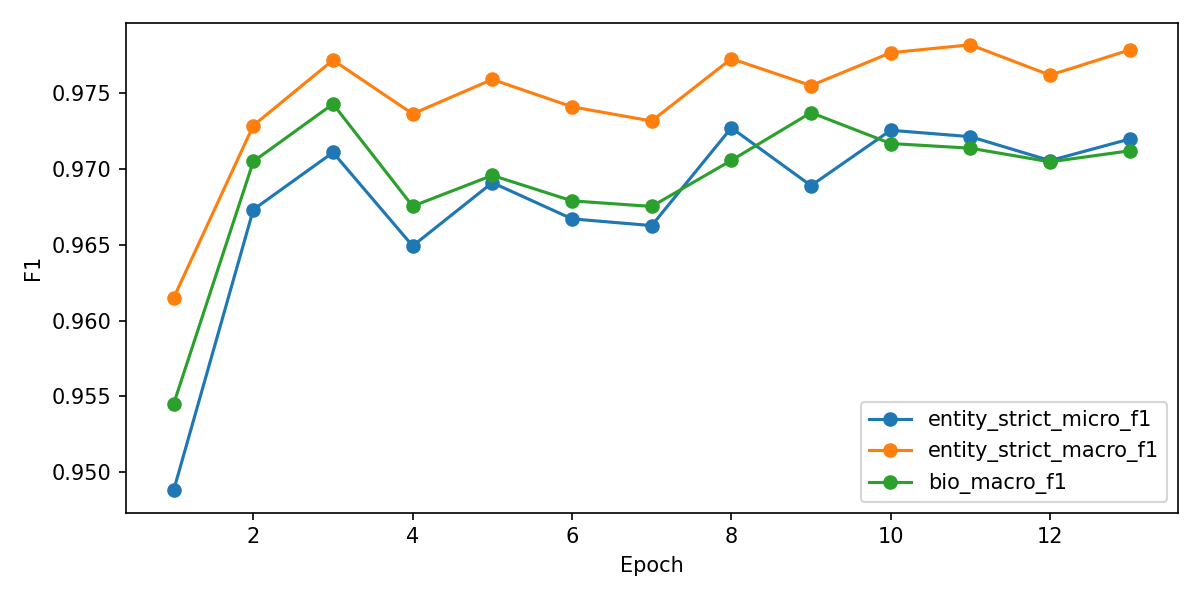

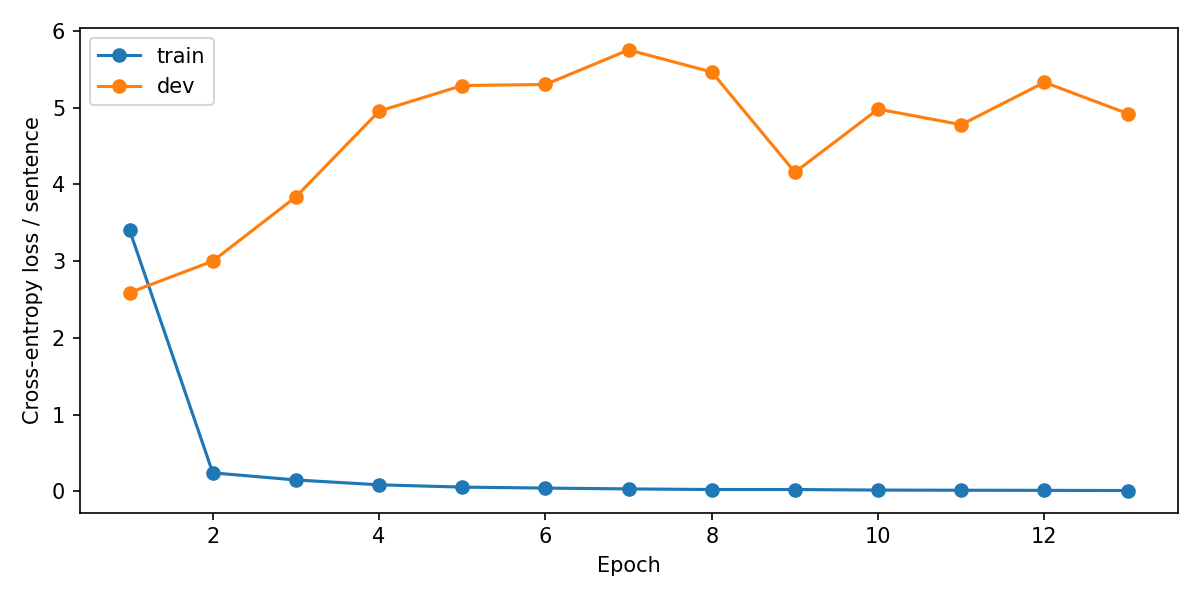

In [18]:
history_path = RUN_DIR / "history.json"
history = json.loads(history_path.read_text(encoding="utf-8"))

for row in history:
    print(
        f"Epoch {row['epoch']:2d}: "
        f"Strict Micro F1={row['entity_strict_micro_f1']:.4%} | "
        f"Strict Macro F1={row['entity_strict_macro_f1']:.4%} | "
        f"BIO Macro F1={row['bio_macro_f1']:.4%} | "
        f"VRAM={row['peak_vram_gib']:.2f} GiB | "
        f"time={row['seconds'] / 60:.1f} min"
    )

plot_source = r"""
import json, sys
from pathlib import Path
import matplotlib.pyplot as plt

out = Path(sys.argv[1])
rows = json.loads((out / "history.json").read_text())

epochs = [r["epoch"] for r in rows]

fig = plt.figure(figsize=(8, 4))
for key in ["entity_strict_micro_f1", "entity_strict_macro_f1", "bio_macro_f1"]:
    plt.plot(epochs, [r[key] for r in rows], marker="o", label=key)
plt.xlabel("Epoch")
plt.ylabel("F1")
plt.legend()
plt.tight_layout()
fig.savefig(out / "training_f1.png", dpi=150)
plt.close(fig)

fig = plt.figure(figsize=(8, 4))
plt.plot(epochs, [r["train_loss_per_sentence"] for r in rows], marker="o", label="train")
plt.plot(epochs, [r["loss_per_sentence"] for r in rows], marker="o", label="dev")
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss / sentence")
plt.legend()
plt.tight_layout()
fig.savefig(out / "training_loss.png", dpi=150)
plt.close(fig)
"""

subprocess.run(
    [str(ENV_PYTHON), "-c", plot_source, str(RUN_DIR)],
    check=True,
    env=ENV,
)

from IPython.display import Image, display
display(Image(filename=str(RUN_DIR / "training_f1.png")))
display(Image(filename=str(RUN_DIR / "training_loss.png")))

## 13. Đánh giá trên test split

Best checkpoint được đánh giá một lần trên test sau khi training hoàn tất.

Output chính:

- `test_metrics.json`
- `test_predictions.json`
- `test_report.txt`

`test_report.txt` có strict entity report theo từng loại entity và BIO token report.


In [19]:
assert (RUN_DIR / "best_model.pt").exists(), "Chưa có best_model.pt"

subprocess.run(
    [str(ENV_PYTHON), "-u", str(RUNNER), "test", "--config", str(CONFIG_PATH)],
    check=True,
    env=ENV,
)

print((RUN_DIR / "test_metrics.json").read_text(encoding="utf-8"))

/workspace/ner-pap/venv-papner-torch2.5.1-cu121/lib/python3.12/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


GPU=NVIDIA GeForce RTX 3090; VRAM=23.6 GiB; precision=fp16


Tokenize test: 10278it [00:16, 630.56it/s]


test: 10,278 sentences (limit=None); 0 truncated; 0 words excluded


Evaluate: 100%|██████████| 322/322 [00:08<00:00, 38.12it/s]


{
  "loss_per_sentence": 4.90532731839551,
  "bio_accuracy": 0.9906943714698542,
  "bio_macro_f1": 0.9726399570929778,
  "entity_strict_precision_micro": 0.983755305136836,
  "entity_strict_recall_micro": 0.9613386089526624,
  "entity_strict_micro_f1": 0.9724177837785708,
  "entity_strict_macro_f1": 0.9741851991649864
}
              precision    recall  f1-score   support

          CQ     0.9823    0.9632    0.9727      7311
          NG     0.9998    0.9990    0.9994      4021
          SL     0.9727    0.9573    0.9649      1638
        VBPL     0.9736    0.9783    0.9759       828
          ĐT     0.9798    0.9373    0.9581      7179

   micro avg     0.9838    0.9613    0.9724     20977
   macro avg     0.9816    0.9670    0.9742     20977
weighted avg     0.9837    0.9613    0.9723     20977

BIO token report
              precision    recall  f1-score   support

           O     0.9909    0.9985    0.9946    205461
        B-CQ     0.9876    0.9684    0.9779      7311
        I

## 14. Đánh giá nâng cao theo kiểu paper (Strict / Partial / Entity Type / Exact)

Cell này đọc `test_predictions.json` và dựng bảng tương tự hình bạn gửi: theo từng tag và có cả dòng **Micro / Macro** cho 4 chế độ đánh giá.


In [20]:

from IPython.display import HTML, display

assert (RUN_DIR / "test_predictions.json").exists(), "Chưa có test_predictions.json. Hãy chạy cell đánh giá test trước."

advanced_eval_script = r"""
import json
from pathlib import Path

import pandas as pd
from nervaluate import Evaluator

run_dir = Path(r"__RUN_DIR__")
pred_path = run_dir / "test_predictions.json"
raw = json.loads(pred_path.read_text(encoding="utf-8"))
true_seqs = raw["gold"]
pred_seqs = raw["pred"]
entity_tags = ["CQ", "ĐT", "VBPL", "NG", "SL"]

evaluator = Evaluator(true_seqs, pred_seqs, tags=entity_tags, loader="list")
results, results_by_tag, _, _ = evaluator.evaluate()

modes = [
    ("strict", "Strict"),
    ("partial", "Partial"),
    ("ent_type", "Entity Type"),
    ("exact", "Exact"),
]


def unpack_metrics(obj):
    if isinstance(obj, dict):
        src = obj
    else:
        src = {
            name: getattr(obj, name)
            for name in [
                "correct", "incorrect", "partial", "missed", "spurious",
                "possible", "actual", "precision", "recall", "f1"
            ]
            if hasattr(obj, name)
        }
    out = {}
    for key, value in src.items():
        if isinstance(value, (int, float)):
            out[key] = float(value)
        else:
            out[key] = value
    return out

rows = []
for tag in entity_tags:
    row = {("Tag", ""): tag}
    tag_block = results_by_tag.get(tag) or {mode_key: {} for mode_key, _ in modes}
    for mode_key, mode_name in modes:
        metrics = unpack_metrics(tag_block[mode_key])
        row[(mode_name, "P")] = metrics.get("precision", 0.0) * 100.0
        row[(mode_name, "R")] = metrics.get("recall", 0.0) * 100.0
        row[(mode_name, "F1")] = metrics.get("f1", 0.0) * 100.0
    rows.append(row)

micro_row = {("Tag", ""): "Micro"}
for mode_key, mode_name in modes:
    metrics = unpack_metrics(results[mode_key])
    micro_row[(mode_name, "P")] = metrics.get("precision", 0.0) * 100.0
    micro_row[(mode_name, "R")] = metrics.get("recall", 0.0) * 100.0
    micro_row[(mode_name, "F1")] = metrics.get("f1", 0.0) * 100.0
rows.append(micro_row)

macro_row = {("Tag", ""): "Macro"}
for mode_key, mode_name in modes:
    p_vals = [r[(mode_name, "P")] for r in rows[:-1]]
    r_vals = [r[(mode_name, "R")] for r in rows[:-1]]
    f_vals = [r[(mode_name, "F1")] for r in rows[:-1]]
    macro_row[(mode_name, "P")] = sum(p_vals) / len(p_vals)
    macro_row[(mode_name, "R")] = sum(r_vals) / len(r_vals)
    macro_row[(mode_name, "F1")] = sum(f_vals) / len(f_vals)
rows.append(macro_row)

columns = [("Tag", "")]
for _, mode_name in modes:
    columns.extend([(mode_name, "P"), (mode_name, "R"), (mode_name, "F1")])

df = pd.DataFrame(rows)[columns]
flat_df = df.copy()
flat_df.columns = [
    "Tag" if a == "Tag" else f"{a}_{b}"
    for a, b in flat_df.columns
]

csv_path = run_dir / "advanced_eval_table.csv"
html_path = run_dir / "advanced_eval_table.html"
json_path = run_dir / "advanced_eval_summary.json"
md_path = run_dir / "advanced_eval_table.md"

flat_df.to_csv(csv_path, index=False, encoding="utf-8-sig")

styled = (
    df.style
    .format(precision=2, na_rep="-")
    .hide(axis="index")
    .set_caption("PAP_NER evaluation table — Strict / Partial / Entity Type / Exact")
)
html_path.write_text(styled.to_html(), encoding="utf-8")
md_path.write_text(flat_df.to_markdown(index=False, floatfmt=".2f"), encoding="utf-8")
json_path.write_text(json.dumps({
    "overall": {k: unpack_metrics(v) for k, v in results.items()},
    "by_tag": {
        tag: {mode_key: unpack_metrics(mode_block[mode_key]) for mode_key, _ in modes}
        for tag, mode_block in results_by_tag.items()
    },
}, ensure_ascii=False, indent=2), encoding="utf-8")

print(csv_path)
print(html_path)
print(json_path)
print(md_path)
""".replace("__RUN_DIR__", str(RUN_DIR))

subprocess.run([str(ENV_PYTHON), "-c", advanced_eval_script], check=True, env=ENV)

for path in [
    RUN_DIR / "advanced_eval_table.csv",
    RUN_DIR / "advanced_eval_table.html",
    RUN_DIR / "advanced_eval_summary.json",
    RUN_DIR / "advanced_eval_table.md",
]:
    assert path.exists(), f"Thiếu file: {path}"

print("Đã tạo các file đánh giá nâng cao:")
print("-", RUN_DIR / "advanced_eval_table.csv")
print("-", RUN_DIR / "advanced_eval_table.html")
print("-", RUN_DIR / "advanced_eval_summary.json")
print("-", RUN_DIR / "advanced_eval_table.md")

display(HTML((RUN_DIR / "advanced_eval_table.html").read_text(encoding="utf-8")))
print((RUN_DIR / "advanced_eval_table.md").read_text(encoding="utf-8"))


/workspace/ner-pap/runs/papner_electra_softmax_20ep_rtx3090_24gb/advanced_eval_table.csv
/workspace/ner-pap/runs/papner_electra_softmax_20ep_rtx3090_24gb/advanced_eval_table.html
/workspace/ner-pap/runs/papner_electra_softmax_20ep_rtx3090_24gb/advanced_eval_summary.json
/workspace/ner-pap/runs/papner_electra_softmax_20ep_rtx3090_24gb/advanced_eval_table.md
Đã tạo các file đánh giá nâng cao:
- /workspace/ner-pap/runs/papner_electra_softmax_20ep_rtx3090_24gb/advanced_eval_table.csv
- /workspace/ner-pap/runs/papner_electra_softmax_20ep_rtx3090_24gb/advanced_eval_table.html
- /workspace/ner-pap/runs/papner_electra_softmax_20ep_rtx3090_24gb/advanced_eval_summary.json
- /workspace/ner-pap/runs/papner_electra_softmax_20ep_rtx3090_24gb/advanced_eval_table.md


"('Tag', '')","('Strict', 'P')","('Strict', 'R')","('Strict', 'F1')","('Partial', 'P')","('Partial', 'R')","('Partial', 'F1')","('Entity Type', 'P')","('Entity Type', 'R')","('Entity Type', 'F1')","('Exact', 'P')","('Exact', 'R')","('Exact', 'F1')"
CQ,98.04,96.32,97.17,98.42,96.70,97.55,98.66,96.94,97.79,98.04,96.32,97.17
ĐT,98.06,93.75,95.86,98.99,94.63,96.76,99.80,95.40,97.55,98.12,93.80,95.91
VBPL,96.10,98.31,97.19,96.75,98.97,97.85,97.40,99.64,98.51,96.10,98.31,97.19
NG,99.90,99.90,99.90,99.94,99.94,99.94,99.98,99.98,99.98,99.90,99.90,99.90
SL,96.08,95.73,95.91,97.67,97.32,97.50,99.27,98.90,99.08,96.08,95.73,95.91
Micro,98.18,96.16,97.16,98.78,96.75,97.75,99.29,97.25,98.26,98.19,96.18,97.18
Macro,97.64,96.80,97.21,98.35,97.51,97.92,99.02,98.17,98.58,97.65,96.81,97.22


| Tag   |   Strict_P |   Strict_R |   Strict_F1 |   Partial_P |   Partial_R |   Partial_F1 |   Entity Type_P |   Entity Type_R |   Entity Type_F1 |   Exact_P |   Exact_R |   Exact_F1 |
|:------|-----------:|-----------:|------------:|------------:|------------:|-------------:|----------------:|----------------:|-----------------:|----------:|----------:|-----------:|
| CQ    |      98.04 |      96.32 |       97.17 |       98.42 |       96.70 |        97.55 |           98.66 |           96.94 |            97.79 |     98.04 |     96.32 |      97.17 |
| ĐT    |      98.06 |      93.75 |       95.86 |       98.99 |       94.63 |        96.76 |           99.80 |           95.40 |            97.55 |     98.12 |     93.80 |      95.91 |
| VBPL  |      96.10 |      98.31 |       97.19 |       96.75 |       98.97 |        97.85 |           97.40 |           99.64 |            98.51 |     96.10 |     98.31 |      97.19 |
| NG    |      99.90 |      99.90 |       99.90 |       99.94 |       99.94

## 15. Inference thử với một câu đã word-segment

PAP_NER đã được word-segment. Với văn bản thô mới, hãy chạy VnCoreNLP/RDRSegmenter trước khi đưa vào cell này.


In [21]:
SEGMENTED_TEXT = (
    "Uỷ_ban_nhân_dân tỉnh Thái_Bình ban_hành Nghị_định 123/2020/NĐ-CP "
    "ngày 15 tháng 10 năm 2020 về đăng_ký doanh_nghiệp với lệ_phí 5 triệu đồng ."
)

subprocess.run(
    [
        str(ENV_PYTHON),
        "-u",
        str(RUNNER),
        "predict",
        "--config",
        str(CONFIG_PATH),
        "--text",
        SEGMENTED_TEXT,
    ],
    check=True,
    env=ENV,
)

/workspace/ner-pap/venv-papner-torch2.5.1-cu121/lib/python3.12/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


GPU=NVIDIA GeForce RTX 3090; VRAM=23.6 GiB; precision=fp16
Uỷ_ban_nhân_dân                               B-CQ
tỉnh                                          O
Thái_Bình                                     O
ban_hành                                      O
Nghị_định                                     B-VBPL
123/2020/NĐ-CP                                I-VBPL
ngày                                          O
15                                            O
tháng                                         O
10                                            O
năm                                           O
2020                                          O
về                                            O
đăng_ký                                       O
doanh_nghiệp                                  B-ĐT
với                                           O
lệ_phí                                        O
5                                             B-SL
triệu                                         I-SL
đồng   

CompletedProcess(args=['/workspace/ner-pap/venv-papner-torch2.5.1-cu121/bin/python', '-u', '/workspace/ner-pap/papner_multimodel_classifier_runner.py', 'predict', '--config', '/workspace/ner-pap/runs/papner_electra_softmax_20ep_rtx3090_24gb/launch_config.json', '--text', 'Uỷ_ban_nhân_dân tỉnh Thái_Bình ban_hành Nghị_định 123/2020/NĐ-CP ngày 15 tháng 10 năm 2020 về đăng_ký doanh_nghiệp với lệ_phí 5 triệu đồng .'], returncode=0)

## 16. Đóng gói kết quả


In [22]:
import zipfile
from IPython.display import FileLink, display

ARCHIVE_PATH = NOTEBOOK_DIR / f"{RUN_NAME}-results.zip"

items = [
    "best_model.pt",
    "run_config.json",
    "launch_config.json",
    "dataset_stats.json",
    "history.json",
    "test_metrics.json",
    "test_predictions.json",
    "test_report.txt",
    "advanced_eval_table.csv",
    "advanced_eval_table.html",
    "advanced_eval_summary.json",
    "advanced_eval_table.md",
    "requirements-frozen.txt",
    "training_f1.png",
    "training_loss.png",
]

with zipfile.ZipFile(
    ARCHIVE_PATH,
    "w",
    compression=zipfile.ZIP_DEFLATED,
    compresslevel=1,
) as archive:
    for name in items:
        path = RUN_DIR / name
        if path.exists():
            archive.write(path, arcname=f"{RUN_NAME}/{name}")

    for directory in ["tokenizer", "model_config"]:
        base = RUN_DIR / directory
        if base.exists():
            for path in base.rglob("*"):
                if path.is_file():
                    archive.write(
                        path,
                        arcname=f"{RUN_NAME}/{path.relative_to(RUN_DIR)}",
                    )

    archive.write(RUNNER, arcname=f"{RUN_NAME}/papner_multimodel_classifier_runner.py")

print(f"ZIP: {ARCHIVE_PATH} ({ARCHIVE_PATH.stat().st_size / 2**20:.1f} MiB)")
display(FileLink(str(ARCHIVE_PATH)))
print("Resume checkpoint:", RUN_DIR / "last_checkpoint.pt")


ZIP: /workspace/PAP_NER_ELECTRA_SOFTMAX_VAST_RTX3090_24GB/papner_electra_softmax_20ep_rtx3090_24gb-results.zip (391.7 MiB)


/workspace/PAP_NER_ELECTRA_SOFTMAX_VAST_RTX3090_24GB/papner_electra_softmax_20ep_rtx3090_24gb-results.zip

Resume checkpoint: /workspace/ner-pap/runs/papner_electra_softmax_20ep_rtx3090_24gb/last_checkpoint.pt


## 17. Tùy chọn: dừng process train

Cell này mặc định **không làm gì**. Chỉ đổi `STOP_TRAIN=True` khi thật sự muốn dừng.


In [ ]:
STOP_TRAIN = False

if STOP_TRAIN:
    import signal

    current_pid = int(PID_PATH.read_text())
    current_cmd = Path(f"/proc/{current_pid}/cmdline")

    if (
        process_alive(current_pid)
        and current_cmd.exists()
        and str(CONFIG_PATH).encode() in current_cmd.read_bytes()
    ):
        os.kill(current_pid, signal.SIGTERM)
        print(f"Đã gửi SIGTERM tới PID={current_pid}")
    else:
        print("Không có process train của run này đang chạy.")